In [1]:
#check python version
!python --version
# for Colab
%tensorflow_version 2.x
# upgrade latest version
!pip install --upgrade tensorflow
# upgrade
!pip install --upgrade tensorflow===2.1.0
# install latest version
!pip install tensorflow
# install 
!pip install tensorflow===2.1.0

Python 3.10.12


UsageError: Line magic function `%tensorflow_version` not found.


In [2]:
import numpy as np
import math
import tensorflow as tf
print('TensorFlow', tf.__version__)

2023-09-18 12:08:23.194279: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow 2.12.0


In [ ]:
# mnist 
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

In [ ]:
train_images.shape

In [ ]:
test_images.shape

In [ ]:
max(train_images)

In [ ]:
train_labels.shape

In [ ]:
INPUT_FEATURES = 2 
LAYER1_NEURONS = 3 
LAYER2_NEURONS = 3 
LAYER3_NEURONS = 1 

In [ ]:
class NeuralNetwork(tf.keras.Model):

  def __init__(self, *args, **kwargs):
    super().__init__(*args, **kwargs)

    self.layer1 = tf.keras.layers.Dense(units=LAYER1_NEURONS)
    self.layer2 = tf.keras.layers.Dense(units=LAYER2_NEURONS)
    self.layer3 = tf.keras.layers.Dense(units=LAYER3_NEURONS)
    
  def call(self, x, training=None):
    x = self.layer1(x)
    x = self.layer2(x)
    x = self.layer3(x)
    return x
  
model = NeuralNetwork()


In [ ]:
class VGG(tf.keras.Model):

  def __init__(self, *args, **kwargs):
    super().__init__(*args, **kwargs)

    self.layer1 = tf.keras.layers.Conv2D(3,(3,3),padding='same')
    self.layer2 = tf.keras.layers.Conv2D(3,(3,3),padding='same')
    self.layer3 = tf.keras.layers.Conv2D(3,(3,3),padding='same')
    
  def call(self, x, training=None):
    x = self.layer1(x)
    x = self.layer2(x)
    x = self.layer3(x)
    return x
  
model = VGG()


In [9]:
config = [64, 'B', 'R' , 64, 'B', 'R' , 'M', 128, 'B', 'R', 128, 'B', 'R','M', 1]

In [10]:
def make_layers(config):
    layers = []
    for v in config:
        if v == 'M':
            layers += [tf.keras.layers.MaxPooling2D(pool_size=(2, 2),strides=None,padding='same',data_format=None)]
        elif v == 'B':
            layers += [tf.keras.layers.BatchNormalization(axis=-1,momentum=0.99,epsilon=0.001)]
        elif v == 'R':
            layers += [tf.keras.layers.ReLU(max_value=None, negative_slope=0.0, threshold=0.0)]
        else:
            layers += [tf.keras.layers.Conv2D(v,kernel_size=(3,3),strides=(1, 1),padding='same')]
    return tf.keras.models.Sequential(layers)

In [ ]:
model = make_layers(config)

In [32]:
class TFVGG(tf.keras.Model):
    def __init__(self, features, num_classes=10):
        super(TFVGG, self).__init__()
        self.features = features
        self.flatten = tf.keras.layers.Flatten()
        self.classifier = tf.keras.Sequential([
            tf.keras.layers.Dense(100, activation='relu'),
            tf.keras.layers.Dense(100, activation='relu'),
            tf.keras.layers.Dense(num_classes,activation=tf.keras.activations.softmax)])
    def call(self, x):
        x = self.features(x) # [B,H,W,C]
        x = tf.transpose(x, perm=[0,3,1,2]) # [B,C,H,W]
        x = self.flatten(x)
        x = self.classifier(x)
        return x
model = TFVGG(make_layers(config))

In [ ]:
class TFVGG(tf.keras.Model):
    def __init__(self, features, num_classes=10):
        super(TFVGG, self).__init__()
        self.features = features
        self.flatten = tf.keras.layers.Flatten()
        self.classifier = tf.keras.Sequential([
            tf.keras.layers.Dense(4096, activation='relu'),
            tf.keras.layers.Dropout(0.5),
            tf.keras.layers.Dense(4096, activation='relu'),
            tf.keras.layers.Dropout(0.5),
            tf.keras.layers.Dense(num_classes)])
    def call(self, x):
        x = self.features(x) # [B,H,W,C]
        x = tf.transpose(x, perm=[0,3,1,2]) # [B,C,H,W]
        x = self.flatten(x)
        x = self.classifier(x)
        return x
model = TFVGG(make_layers(config))

In [ ]:
class TFVGG_detection(tf.keras.Model):
    def __init__(self, features, num_classes=10):
        super().__init__()
        self.features = features
    def call(self, x):
        x = self.features(x) # [B,H,W,C]
        x = tf.transpose(x, perm=[0,3,1,2]) # [B,C,H,W]
        return x
model = TFVGG_detection(make_layers(config))

In [20]:
INPUT_FEATURES=(28,28,1)

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 sequential_2 (Sequential)   (None, 7, 7, 1)           261697    
                                                                 
 tf.compat.v1.transpose_1 (T  (None, 1, 7, 7)          0         
 FOpLambda)                                                      
                                                                 
 flatten_1 (Flatten)         (None, 49)                0         
                                                                 
 sequential_3 (Sequential)   (None, 10)                16110     
                                                                 
Total params: 277,807
Trainable params: 277,039
Non-trainable params: 768
___________________________________________________

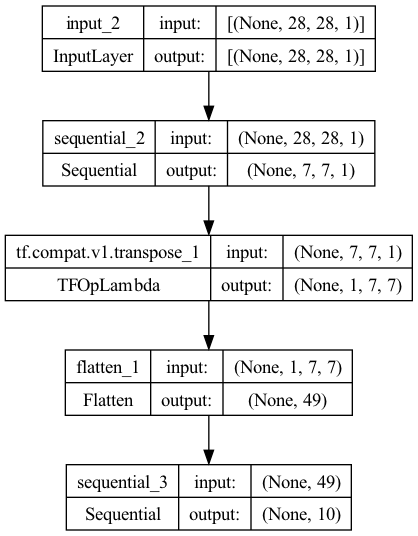

In [21]:
def get_functional_model(model):
  x = tf.keras.layers.Input(shape=(INPUT_FEATURES))
  model = tf.keras.Model(inputs=[x],outputs=model.call(x))
  return model

functional_model = get_functional_model(model)

functional_model.summary()
with open("model_summary.txt", "w") as fp:
    functional_model.summary(print_fn=lambda x: fp.write(x + "\r\n"))

tf.keras.utils.plot_model(functional_model, show_shapes=True, show_layer_names=True, to_file='./model/model.png')
from IPython.display import Image
Image(retina=False, filename='./model/model.png')

In [22]:
INPUT_FEATURES=(28,28,3)

In [ ]:
def get_functional_model(model):
  x = tf.keras.layers.Input(shape=(INPUT_FEATURES))
  model = tf.keras.Model(inputs=[x],outputs=model.call(x))
  return model

functional_model = get_functional_model(model)

functional_model.summary()
with open("model_summary.txt", "w") as fp:
    functional_model.summary(print_fn=lambda x: fp.write(x + "\r\n"))

tf.keras.utils.plot_model(functional_model, show_shapes=True, show_layer_names=True, to_file='./model/model.png')
from IPython.display import Image
Image(retina=False, filename='./model/model.png')

In [33]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.03)

In [ ]:
criterion = tf.keras.losses.CategoricalCrossentropy()

In [34]:
criterion = tf.keras.losses.SparseCategoricalCrossentropy()

In [35]:
model.compile(optimizer=optimizer, loss=criterion, metrics=['accuracy'])

In [17]:
model.fit(train_images, train_labels,epochs=1)

NameError: name 'train_images' is not defined

In [ ]:
predict = model.predict(test_images)

In [ ]:
model.save('my_model')


In [ ]:
model = tf.keras.models.load_model('my_model')

In [ ]:
class MnistSequence(tf.keras.utils.Sequence):

    def __init__(self, training, batch_size):
        if training == True:
            (self.x, self.y), _ = tf.keras.datasets.mnist.load_data()
        else:
            _ , (self.x, self.y) = tf.keras.datasets.mnist.load_data()
        self.batch_size = batch_size

    def __len__(self):
        return math.ceil(len(self.x) / self.batch_size)

    def __getitem__(self, idx):
        low = idx * self.batch_size
        # Cap upper bound at array length; the last batch may be smaller
        # if the total number of items is not a multiple of batch size.
        high = min(low + self.batch_size, len(self.x))
        batch_x = self.x[low:high]
        batch_y = self.y[low:high]

        return np.array(batch_x), np.array(batch_y)

    def on_epoch_end(self):
        pass

In [ ]:
class MnistSequence(tf.keras.utils.Sequence):

    def __init__(self, training, batch_size):
        if training == True:
            (self.x, self.y), _ = tf.keras.datasets.mnist.load_data()
        else:
            _ , (self.x, self.y) = tf.keras.datasets.mnist.load_data()
        self.batch_size = batch_size
        self.indices = np.arange(len(self.x))
        np.random.shuffle(self.indices)

    def __len__(self):
        return math.ceil(len(self.x) / self.batch_size)

    def __getitem__(self, idx):
        inds = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_x = self.x[inds]
        batch_y = self.y[inds]

        return np.array(batch_x), np.array(batch_y)
    
    def on_epoch_end(self):
        np.random.shuffle(self.indices)

In [ ]:
class MnistSequence(tf.keras.utils.Sequence):

    def _shuffle(self):
        self.num_iteration = 0
        np.random.shuffle(self.indices)
        
    def __init__(self, training, batch_size):
        if training == True:
            (self.x, self.y), _ = tf.keras.datasets.mnist.load_data()
        else:
            _ , (self.x, self.y) = tf.keras.datasets.mnist.load_data()

        self.indices = np.arange(len(self.x))
        self.batch_size = batch_size
        self.steps_per_epoch = math.ceil(len(self.x) / self.batch_size)

        self._shuffle()

    def __len__(self):
        return self.steps_per_epoch

    def __getitem__(self, idx):
        inds = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_x = self.x[inds]
        batch_y = self.y[inds]

        if self.num_iteration == (self.steps_per_epoch -1 ):
            self._shuffle()
        else:
            self.num_iteration == self.num_iteration + 1

        return np.array(batch_x), np.array(batch_y)
    
    def on_epoch_end(self):
        pass

In [ ]:
class MnistSequence(tf.keras.utils.Sequence):

    def _shuffle(self):
        np.random.shuffle(self.indices)
        
    def __init__(self, training, batch_size):
        if training == True:
            (self.x, self.y), _ = tf.keras.datasets.mnist.load_data()
        else:
            _ , (self.x, self.y) = tf.keras.datasets.mnist.load_data()

        self.indices = np.arange(len(self.x))
        self.batch_size = batch_size
        self.steps_per_epoch = math.ceil(len(self.x) / self.batch_size)

        self._shuffle()

    def __len__(self):
        return self.steps_per_epoch

    def __getitem__(self, idx):
        inds = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_x = self.x[inds]
        batch_y = self.y[inds]

        return np.array(batch_x), np.array(batch_y)
    
    def on_epoch_end(self):
        self._shuffle

In [36]:
class MnistSequence(tf.keras.utils.Sequence):
        
    def __init__(self, training, batch_size):
        if training == True:
            (self.x, self.y), _ = tf.keras.datasets.mnist.load_data()
        else:
            _ , (self.x, self.y) = tf.keras.datasets.mnist.load_data()

        self.indices = np.arange(len(self.x))
        self.batch_size = batch_size
        self.steps_per_epoch = math.ceil(len(self.x) / self.batch_size)

    def __len__(self):
        return self.steps_per_epoch

    def __getitem__(self, idx):
        inds = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_x = self.x[inds]
        batch_y = self.y[inds]

        return np.array(batch_x/255.0), np.array(batch_y)
    
    def on_epoch_end(self):
        pass

In [ ]:
lass ReccurentTrainingGenerator(Sequence):
    """ Reccurent レイヤーを訓練するためのデータgeneratorクラス """
    def _resetindices(self):
        """バッチとして出力するデータのインデックスを乱数で生成する """
        self.num_called = 0 # 同一のエポック内で __getitem__　メソッドが呼び出された回数
        
        all_idx = np.random.permutation(np.arange(self.num_samples))
        remain_idx = np.random.choice(np.arange(self.num_samples),
                                      size=(self.steps_per_epoch*self.batch_size-len(all_idx)),
                                      replace=False)
        self.indices = np.hstack([all_idx, remain_idx]).reshape(self.steps_per_epoch, self.batch_size)
        
    def __init__(self, x_set, y_set, batch_size, timesteps, delay):
        """
        x_set     : 説明変数 (データ点数×特徴量数)のNumPy配列
        y_set     : 目的変数 (データ点数×1)のNumPy配列
        batch_size: バッチサイズ
        timesteps : どの程度過去からデータをReccurent層に与えるか
        delay     : 目的変数をどの程度遅らせるか
        """
        self.x = np.array(x_set)
        self.y = np.array(y_set)
        self.batch_size = batch_size
        self.steps = timesteps
        self.delay = delay
        
        self.num_samples = len(self.x)-timesteps-delay+1
        self.steps_per_epoch = int(np.ceil( self.num_samples / float(batch_size)))
        
        self._resetindices()
        
    def __len__(self):
        """ 1エポックあたりのステップ数を返す """
        return self.steps_per_epoch
        
    def __getitem__(self, idx):
        """ データをバッチにまとめて出力する """
        indices_temp = self.indices[idx]
        
        batch_x = np.array([self.x[i:i+self.steps] for i in indices_temp])
        batch_y = self.y[indices_temp+self.steps+self.delay-1]
        
        if self.num_called==(self.steps_per_epoch-1):
            self._resetindices() # 1エポック内の全てのバッチを返すと、データをシャッフルする
        else:
            self.num_called += 1
        
        return batch_x, batch_y

In [37]:
datasets_train = MnistSequence(training=True, batch_size=32)
datasets_test  = MnistSequence(training=False,batch_size=1)

In [38]:
model.fit(datasets_train,epochs=1,shuffle=True)

ValueError: Exception encountered when calling layer 'sequential_4' (type Sequential).

Input 0 of layer "conv2d_10" is incompatible with the layer: expected min_ndim=4, found ndim=3. Full shape received: (32, 28, 28)

Call arguments received by layer 'sequential_4' (type Sequential):
  • inputs=tf.Tensor(shape=(32, 28, 28), dtype=float32)
  • training=False
  • mask=None

In [8]:
count = 0
for j in range(2):
    for i,v in enumerate(datasets_test):
        count = count + 1
        last_v = v
        print(count,i,last_v[1])

1 0 [7]
2 1 [2]
3 2 [1]
4 3 [0]
5 4 [4]
6 5 [1]
7 6 [4]
8 7 [9]
9 8 [5]
10 9 [9]
11 10 [0]
12 11 [6]
13 12 [9]
14 13 [0]
15 14 [1]
16 15 [5]
17 16 [9]
18 17 [7]
19 18 [3]
20 19 [4]
21 20 [9]
22 21 [6]
23 22 [6]
24 23 [5]
25 24 [4]
26 25 [0]
27 26 [7]
28 27 [4]
29 28 [0]
30 29 [1]
31 30 [3]
32 31 [1]
33 32 [3]
34 33 [4]
35 34 [7]
36 35 [2]
37 36 [7]
38 37 [1]
39 38 [2]
40 39 [1]
41 40 [1]
42 41 [7]
43 42 [4]
44 43 [2]
45 44 [3]
46 45 [5]
47 46 [1]
48 47 [2]
49 48 [4]
50 49 [4]
51 50 [6]
52 51 [3]
53 52 [5]
54 53 [5]
55 54 [6]
56 55 [0]
57 56 [4]
58 57 [1]
59 58 [9]
60 59 [5]
61 60 [7]
62 61 [8]
63 62 [9]
64 63 [3]
65 64 [7]
66 65 [4]
67 66 [6]
68 67 [4]
69 68 [3]
70 69 [0]
71 70 [7]
72 71 [0]
73 72 [2]
74 73 [9]
75 74 [1]
76 75 [7]
77 76 [3]
78 77 [2]
79 78 [9]
80 79 [7]
81 80 [7]
82 81 [6]
83 82 [2]
84 83 [7]
85 84 [8]
86 85 [4]
87 86 [7]
88 87 [3]
89 88 [6]
90 89 [1]
91 90 [3]
92 91 [6]
93 92 [9]
94 93 [3]
95 94 [1]
96 95 [4]
97 96 [1]
98 97 [7]
99 98 [6]
100 99 [9]
101 100 [6]
102 10